In [1]:
!pip install opencv-python numpy pandas scikit-learn matplotlib seaborn joblib tqdm


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
import joblib


In [5]:
fingerprint_path = r"C:\Users\DELL\Downloads\archive (1)\SOCOFing\Real"
diabetes_path = r"C:\Users\DELL\Downloads\archive (2)\diabetes_prediction_dataset.csv"


In [6]:
def extract_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    
    # Basic statistical features
    mean_intensity = np.mean(img)
    std_intensity = np.std(img)
    
    # Edge detection for ridge estimation
    edges = cv2.Canny(img, 50, 150)
    ridge_density = np.sum(edges) / (128*128)
    
    # Texture variance
    texture_variance = np.var(img)
    
    return [mean_intensity, std_intensity, ridge_density, texture_variance]


In [7]:
fingerprint_features = []

image_files = os.listdir(fingerprint_path)

for file in tqdm(image_files):
    img_path = os.path.join(fingerprint_path, file)
    features = extract_features(img_path)
    fingerprint_features.append(features)

fingerprint_df = pd.DataFrame(
    fingerprint_features,
    columns=["fp_mean", "fp_std", "fp_ridge_density", "fp_texture_var"]
)

print("Fingerprint Dataset Shape:", fingerprint_df.shape)
fingerprint_df.head()


100%|█████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:21<00:00, 280.49it/s]


Fingerprint Dataset Shape: (6000, 4)


,fp_mean,fp_std,fp_ridge_density,fp_texture_var
0,129.777771,90.120326,79.173889,8121.673087
1,144.518555,99.234290,66.582642,9847.444358
2,128.066040,86.897011,84.123230,7551.090487
3,137.108337,90.118027,77.306213,8121.258832
4,143.517883,86.542363,86.084290,7489.580613


In [8]:
diabetes_df = pd.read_csv(diabetes_path)

print("Diabetes Dataset Shape:", diabetes_df.shape)
diabetes_df.head()


Diabetes Dataset Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [9]:
print(diabetes_df.columns)


Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [10]:
min_rows = min(len(fingerprint_df), len(diabetes_df))

fingerprint_df = fingerprint_df.iloc[:min_rows]
diabetes_df = diabetes_df.iloc[:min_rows]

print("Aligned rows:", len(fingerprint_df))


Aligned rows: 6000


In [11]:
label_column = "diabetes"   # change if needed

y = diabetes_df[label_column]
diabetes_features = diabetes_df.drop(label_column, axis=1)

merged_df = pd.concat([fingerprint_df, diabetes_features], axis=1)
merged_df[label_column] = y

print("Final Merged Shape:", merged_df.shape)
merged_df.head()


Final Merged Shape: (6000, 13)


,fp_mean,fp_std,fp_ridge_density,fp_texture_var,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,129.777771,90.120326,79.173889,8121.673087,Female,80.0,0,1,never,25.19,6.6,140,0
1,144.518555,99.234290,66.582642,9847.444358,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,128.066040,86.897011,84.123230,7551.090487,Male,28.0,0,0,never,27.32,5.7,158,0
3,137.108337,90.118027,77.306213,8121.258832,Female,36.0,0,0,current,23.45,5.0,155,0
4,143.517883,86.542363,86.084290,7489.580613,Male,76.0,1,1,current,20.14,4.8,155,0


In [12]:
X = merged_df.drop(label_column, axis=1)
y = merged_df[label_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
# Train-Test Split (No StandardScaler)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (4800, 12)
Testing shape: (1200, 12)


In [14]:
X = pd.get_dummies(X, drop_first=True)



In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (4800, 16)
Testing Shape: (1200, 16)


In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed ✅")


Model Training Completed ✅


In [17]:
y_pred = model.predict(X_test)


In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9783333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1102
           1       1.00      0.73      0.85        98

    accuracy                           0.98      1200
   macro avg       0.99      0.87      0.92      1200
weighted avg       0.98      0.98      0.98      1200



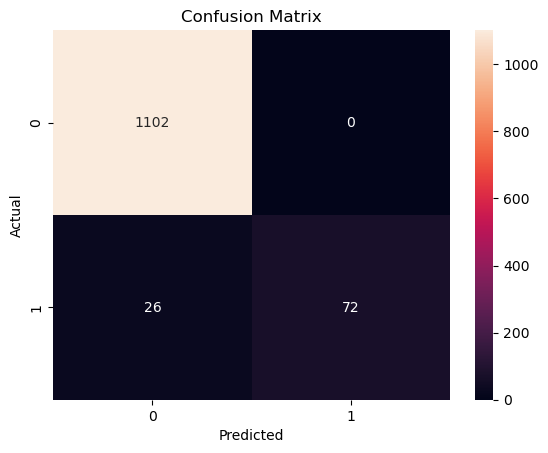

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


                        Feature  Importance
8                   HbA1c_level    0.385162
9           blood_glucose_level    0.265882
7                           bmi    0.065159
4                           age    0.058376
0                       fp_mean    0.045376
2              fp_ridge_density    0.043588
3                fp_texture_var    0.043008
1                        fp_std    0.042546
5                  hypertension    0.013574
6                 heart_disease    0.009799
13       smoking_history_former    0.006513
10                  gender_Male    0.006498
14        smoking_history_never    0.005664
15  smoking_history_not current    0.003581
11      smoking_history_current    0.003266
12         smoking_history_ever    0.002009


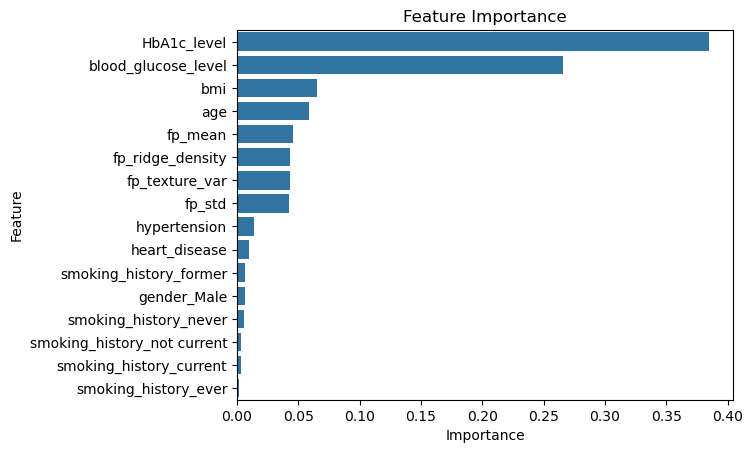

In [20]:
import pandas as pd

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()


In [21]:
import joblib

joblib.dump(model, "fingerprint_diabetes_model.pkl")

print("Model Saved Successfully ✅")


Model Saved Successfully ✅


In [22]:
import joblib

joblib.dump(model, "Fingerprint based Diabetes detection.pkl")

['Fingerprint based Diabetes detection.pkl']

In [23]:
import os
print(os.getcwd())

C:\Users\DELL


In [24]:
print(list(X.columns))

['fp_mean', 'fp_std', 'fp_ridge_density', 'fp_texture_var', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']
